We generate spike trains from the mean reverting process with Ornstein-Uhlenbeck noise.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

plt.rcParams.update({
    "text.usetex": True,  # Enable LaTeX rendering
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"], # Specify the font (classic LaTeX font)
    # You might need to adjust the font paths or preamble depending on your setup
    "text.latex.preamble": r"\usepackage{amsmath}" # Example if you need math packages
})

In [64]:
# Simulation parameters.
T = 1.0                 # Total simulation time.
tau_e = 0.0375           # Correlation decay parameter for the process.
# tau_e = 0.0125           # Correlation decay parameter for the process.
tau_f = 0.003            # Second correlation parameter.
dt = 0.05 * min(tau_e, tau_f)  # Time discretization step.
sigma = 1.0             # Standard deviation (amplitude) of the process.

u = 0.3

In [74]:
# simulation using the fft code
t, x = utils.simulate_gaussian_process_fft(process.r_OU_noise, T, dt, sigma=sigma, tau=tau_e, kappa=tau_f/tau_e)
model = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u, tau=tau_e, kappa=tau_f/tau_e, sigma=sigma)
fano_factor = model.upcrossing_fano_factor_CLT(epsilon_left=1e-5, epsilon_right=1e-5)
print(f"Fano factor: {fano_factor}")

Fano factor: 1.580888657024001


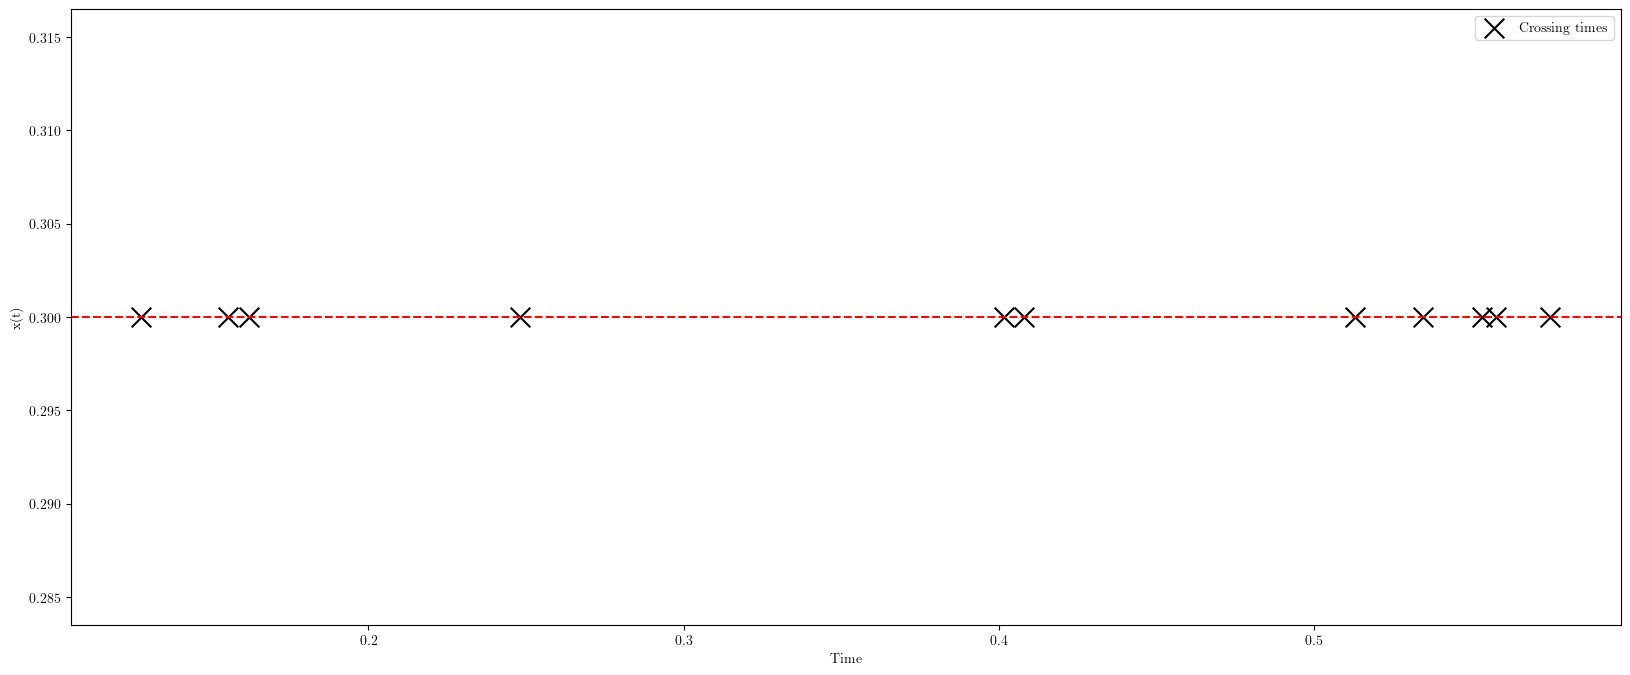

In [75]:

time = utils.upcrossing_times(x, t=t, threshold=u)

# Plot the result.
plt.figure(figsize=(20, 8))
# plt.plot(t, x)
# plot a linea t the threshold
plt.axhline(y=u, color='r', linestyle='--')
# plot scatter plot a t threshold and crossing times
plt.scatter(time, u * np.ones_like(time), color='black', marker='x', label='Crossing times', s=200)
# plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
# plt.title('Squared exponential')
plt.legend()
# plt.grid(True)
plt.show()

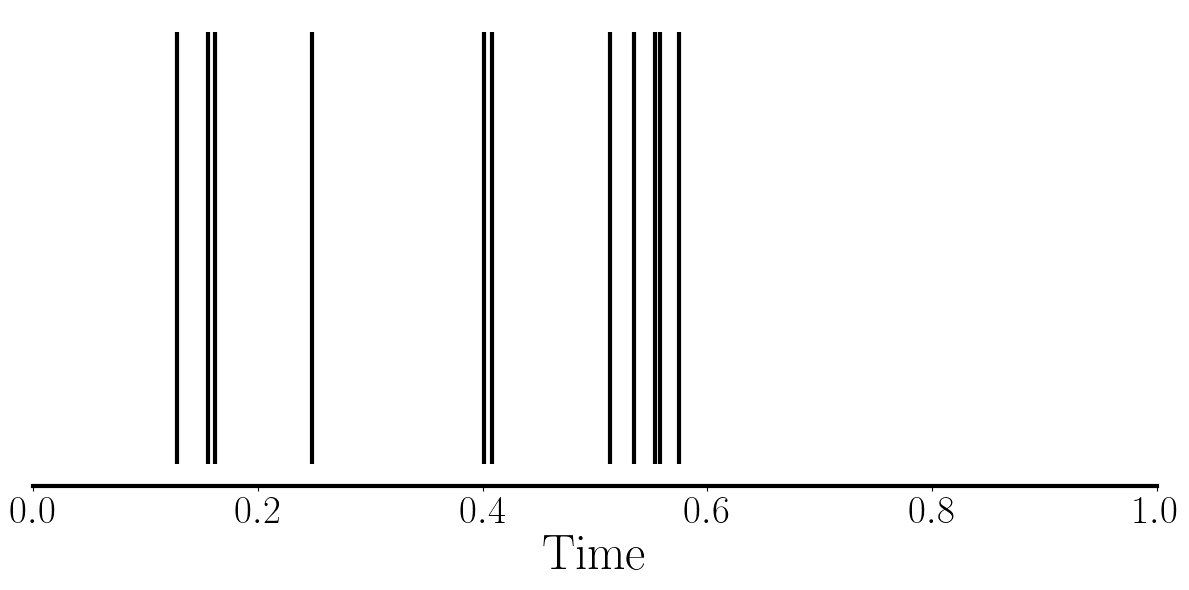

In [76]:

# Create the figure
plt.figure(figsize=(12, 6))

# Plot vertical lines at each upcrossing time, making them 3 times thicker
if len(time) > 0:
    plt.vlines(x=time, ymin=0, ymax=1, color='black', linewidth=3)

# Set the x-axis label with a much larger font size
plt.xlabel('Time', fontsize=36)
plt.xlim(0, T)

# Get current axes to modify them
ax = plt.gca()

# Make the x-axis ticks and their labels way larger
ax.tick_params(axis='x', which='major', labelsize=28)

# Remove the y-axis and the top and side borders of the plot
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Make the x-axis line itself thicker to match the new style
ax.spines['bottom'].set_linewidth(3)

# Ensure the layout is tight
plt.tight_layout()

# save the figure with the name fano_0.71
# plt.savefig('fano_0.71.png', dpi=300, bbox_inches='tight')
plt.savefig('fano_1.58.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()